In [1]:
import shutil
import os

import torch
import torch.nn as nn

import boda

/proj/bmfm/users/sanjoy/miniforge3/envs/malinois_python311/lib/python3.11/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


# Load models interactively

This notebook describes how to load Malinois and use it for inference. It's important to remember that Malinois processes `(bsz, 4, 600)` tensors but was trained on 200-mers. Therefore you need to pad input sequences with 200 nucleotides on each side from the MPRA vector used to generate the data. This is done using the `FlankBuilder`.

# Get Malinois

Can download directly from a Google Storage bucket you can access.

In [2]:
malinois_path = 'gs://tewhey-public-data/CODA_resources/malinois_artifacts__20211113_021200__287348.tar.gz'
my_model = boda.common.utils.load_model(malinois_path)

Copying gs://tewhey-public-data/CODA_resources/malinois_artifacts__20211113_021200__287348.tar.gz...
/ [1 files][ 49.3 MiB/ 49.3 MiB]                                                
Operation completed over 1 objects/49.3 MiB.                                     
archive unpacked in ./


Loaded model from 20211113_021200 in eval mode


In [3]:
# Search all .vcf files inside the 'gs://tewhey-public-data' directory
vcf_files = boda.common.utils.search_files('gs://tewhey-public-data', '.vcf')

AttributeError: module 'boda.common.utils' has no attribute 'search_files'

In [4]:
input_len = torch.load('./artifacts/torch_checkpoint.pt', weights_only=False)['model_hparams'].input_len
print(f'Input length: {input_len}')

Input length: 600


# Set flanks

MPRA flanks are saved as constants in the `boda` repo. These need to be sized to (1, 4, 200) each and used to init `FlankBuilder`.

In [5]:
left_pad_len = (input_len - 200) // 2
right_pad_len= (input_len - 200) - left_pad_len

left_flank = boda.common.utils.dna2tensor( 
    boda.common.constants.MPRA_UPSTREAM[-left_pad_len:] 
).unsqueeze(0)
print(f'left flank shape: {left_flank.shape}')

right_flank= boda.common.utils.dna2tensor( 
    boda.common.constants.MPRA_DOWNSTREAM[:right_pad_len] 
).unsqueeze(0)
right_flank.shape
print(f'right flank shape: {right_flank.shape}')

flank_builder = boda.common.utils.FlankBuilder(
    left_flank=left_flank,
    right_flank=right_flank,
)

flank_builder.cuda()

left flank shape: torch.Size([1, 4, 200])
right flank shape: torch.Size([1, 4, 200])


FlankBuilder()

# Example call

Using `torch.no_grad()` so the computation graph isn't saved to memory. Since sequences are passed to the model as onehots in `torch.float32` format, we can use `torch.randn` to validate the model setup. Here a batch of 10 variable 200 nt (fake) sequences are being padded to 600 nt, then being passed to the model. Note, `my_model` and `flank_builder` have been set on the GPU using `.cuda()` calls. Therefore, the fake sequence also needs to be sent to `cuda`.

Note: this fake sequence will result in pathological predictions, it's only an illustrative example.

In [6]:
placeholder = torch.randn((10,4,200)).cuda() # Simulate a batch_size x 4 nucleotide x 200 nt long sequence
prepped_seq = flank_builder( placeholder )   # Need to add MPRA flanks

with torch.no_grad():
    print( my_model( prepped_seq ) )


tensor([[-0.8912, -0.9364,  7.0705],
        [-1.0014, -0.8544,  6.3704],
        [ 1.8760,  0.3909,  7.8986],
        [ 2.6931,  0.9593, 13.4681],
        [-0.9025, -1.5124,  4.0810],
        [ 1.6794,  0.7132,  6.7245],
        [-1.6512, -0.9252,  2.6760],
        [-0.7289,  0.0494,  5.4321],
        [-0.3683, -0.8166,  6.4254],
        [ 1.5646, -0.8419,  6.3243]], device='cuda:0')


In [7]:
prepped_seq.shape

torch.Size([10, 4, 600])

# Run on the TeWhey datasets from Siraj et al. 

that I curated from Supp Table 4 with emVar=True... Note that there are a few thousands sample more in the Butts et al. in all cell lines... Also, I curated the dataset using a script on process_snv_datasets of CCC /dccstor/bmfm-targets1/users/sanjoy/tools/boda2 using bmfm env...

In [8]:
import pandas as pd
import numpy as np
import csv
from scipy.stats import pearsonr, spearmanr
import tqdm.notebook as tqdm
import matplotlib.pyplot as plt

In [9]:
input_filename = "/proj/bmfm/datasets/omics/genome/finetune_datasets/snv_mpra_Tewhey/Siraj_data/skew_snv_mpra_Tewhey_K562_emVars_refalt_separate.csv"

mpra_skewness_data = pd.read_table(input_filename, sep=',', header=0)
# Cast 'emVar_K562' to boolean and 'log2Skew_K562' to float and 'log2FC_K562' to float
mpra_skewness_data['emVar_K562'] = mpra_skewness_data['emVar_K562'].astype(bool)
mpra_skewness_data['log2Skew_K562'] = mpra_skewness_data['log2Skew_K562'].astype(float)
mpra_skewness_data['log2FC_K562'] = mpra_skewness_data['log2FC_K562'].astype(float)
print(mpra_skewness_data.columns, mpra_skewness_data.shape, mpra_skewness_data.head())
print(mpra_skewness_data['emVar_K562'].value_counts())
#mpra_19 = mpra_19.loc[ mpra_19.loc[:, ['K562_lfcSE', 'HepG2_lfcSE', 'SKNSH_lfcSE']].max(axis=1) < 1.0 ]


Index(['sequence', 'variant', 'emVar_K562', 'log2FC_K562', 'log2Skew_K562'], dtype='str') (39258, 5)                                             sequence              variant  \
0  TGTGAGGATGTCTCTGCCAACCACAGAGTCCTTGAAGCCAGGGGCA...  chr10:100147097:G:A   
1  TGTGAGGATGTCTCTGCCAACCACAGAGTCCTTGAAGCCAGGGGCA...  chr10:100147097:G:A   
2  GTGGCTCTGGAGGCAGAACGTGCAGCTGTCTTTACCTCTGTCTGCA...  chr10:100148176:A:G   
3  GTGGCTCTGGAGGCAGAACGTGCAGCTGTCTTTACCTCTGTCTGCA...  chr10:100148176:A:G   
4  TGGCAGACATTACTAATTGATCACAGAACTTCTCCTTGCTGAGCCC...  chr10:100156426:A:G   

   emVar_K562  log2FC_K562  log2Skew_K562  
0        True     2.254075       0.456006  
1        True     2.708470       0.456006  
2        True     2.355228       0.721583  
3        True     3.058424       0.721583  
4        True     1.039493       0.823104  
emVar_K562
True    39258
Name: count, dtype: int64


Index(['sequence', 'variant', 'emVar_K562', 'log2FC_K562', 'log2Skew_K562'], dtype='str') (37387, 5)                                             sequence              variant  \
0  TGTGAGGATGTCTCTGCCAACCACAGAGTCCTTGAAGCCAGGGGCA...  chr10:100147097:G:A   
1  TGTGAGGATGTCTCTGCCAACCACAGAGTCCTTGAAGCCAGGGGCA...  chr10:100147097:G:A   
2  GTGGCTCTGGAGGCAGAACGTGCAGCTGTCTTTACCTCTGTCTGCA...  chr10:100148176:A:G   
3  GTGGCTCTGGAGGCAGAACGTGCAGCTGTCTTTACCTCTGTCTGCA...  chr10:100148176:A:G   
4  TGGCAGACATTACTAATTGATCACAGAACTTCTCCTTGCTGAGCCC...  chr10:100156426:A:G   

   emVar_K562  log2FC_K562  log2Skew_K562  
0        True     2.254075       0.456006  
1        True     2.708470       0.456006  
2        True     2.355228       0.721583  
3        True     3.058424       0.721583  
4        True     1.039493       0.823104  
Index(['sequence', 'variant', 'emVar_K562', 'log2FC_K562', 'log2Skew_K562'], dtype='str') (22007, 5)                                             sequence              varia

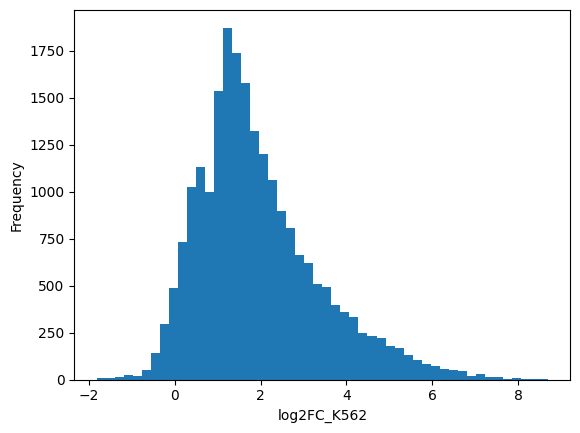

In [10]:
pass_seq = mpra_skewness_data.loc[ mpra_skewness_data['sequence'].str.len() == 201 ].reset_index(drop=True)
print(pass_seq.columns, pass_seq.shape, pass_seq.head())

# Find the sequences that have log2FC_K562 values that are not NaN and log2Skew_K562 greater than 0.5 or less than -0.5
pass_seq = pass_seq.loc[
    pass_seq['log2FC_K562'].notna() & 
    pass_seq['emVar_K562'] &
    (
        (pass_seq['log2Skew_K562'] > 0.5) |
        (pass_seq['log2Skew_K562'] < -0.5)
    )
].reset_index(drop=True)
print(pass_seq.columns, pass_seq.shape, pass_seq.head())

#plot the distribution of log2FC_K562 values...
plt.hist(pass_seq['log2FC_K562'], bins=50)
plt.xlabel('log2FC_K562')
plt.ylabel('Frequency')     
plt.show()

# seq_tensor  = torch.stack([ boda.common.utils.dna2tensor(x['sequence']) for i, x in tqdm.tqdm(pass_seq.iterrows(), total=pass_seq.shape[0]) ], dim=0)
# seq_dataset = torch.utils.data.TensorDataset(seq_tensor)
# seq_loader  = torch.utils.data.DataLoader(seq_dataset, batch_size=128)

In [11]:

seq_tensor  = torch.stack([ boda.common.utils.dna2tensor(x['sequence']) for i, x in tqdm.tqdm(pass_seq.iterrows(), total=pass_seq.shape[0]) ], dim=0)
seq_dataset = torch.utils.data.TensorDataset(seq_tensor)
seq_loader  = torch.utils.data.DataLoader(seq_dataset, batch_size=128)

  0%|          | 0/22007 [00:00<?, ?it/s]

In [12]:
results = []

with torch.no_grad():
    for i, batch in enumerate(tqdm.tqdm(seq_loader)):
        prepped_seq = flank_builder( batch[0].cuda() )
        predictions = my_model( prepped_seq ) + \
                      my_model( prepped_seq.flip(dims=[1,2]) ) # Also
        predictions = predictions.div(2.)
        results.append(predictions.detach().cpu())
                
predictions = torch.cat(results, dim=0) 

  0%|          | 0/172 [00:00<?, ?it/s]

In [13]:
predictions.shape

torch.Size([22007, 3])

In [14]:
pred_df     = pd.DataFrame( predictions.numpy(), columns=['K562_preds', 'HepG2_preds', 'SKNSH_preds'] )
all_results = pd.concat([pass_seq, pred_df], axis=1)
all_results

,sequence,variant,emVar_K562,log2FC_K562,log2Skew_K562,K562_preds,HepG2_preds,SKNSH_preds
0,GTGGCTCTGGAGGCAGAACGTGCAGCTGTCTTTACCTCTGTCTGCA...,chr10:100148176:A:G,True,2.355228,0.721583,0.870769,1.912250,1.992518
1,GTGGCTCTGGAGGCAGAACGTGCAGCTGTCTTTACCTCTGTCTGCA...,chr10:100148176:A:G,True,3.058424,0.721583,1.494322,2.102838,2.540412
2,TGGCAGACATTACTAATTGATCACAGAACTTCTCCTTGCTGAGCCC...,chr10:100156426:A:G,True,1.039493,0.823104,0.652183,1.008606,1.054717
3,TGGCAGACATTACTAATTGATCACAGAACTTCTCCTTGCTGAGCCC...,chr10:100156426:A:G,True,1.803450,0.823104,0.552849,0.953909,0.997828
4,AGCGGGAAGTGTGTGTGGCCCGTCCTGGCCCAGGGACTCAGCCTCA...,chr10:100179851:T:C,True,1.533864,1.020368,1.326769,1.578488,1.044077
...,...,...,...,...,...,...,...,...
22002,TCGCTTGAACCTGGGAAGTGGAGGTTGCAGTGAGCCAAGATTGTGC...,chr9:99224746:A:T,True,0.866300,-0.555676,0.852035,0.916926,1.055230
22003,GACAAAACGTCAACAGTGTCACTGTGGAAAAACCCAGATCTGTGGT...,chr9:99314012:C:T,True,1.227444,-0.786137,0.494812,0.607632,0.328512
22004,GACAAAACGTCAACAGTGTCACTGTGGAAAAACCCAGATCTGTGGT...,chr9:99314012:C:T,True,0.535319,-0.786137,0.322403,0.459346,0.209878
22005,GCAGGAGTAGGAGCAAGACTGAGAGAGGAAAGAGGTGCCACACCCT...,chr9:99911889:A:G,True,1.777891,2.385474,1.345588,1.111853,1.830708


In [17]:
# create a col 'chr' by splitting 'variant' on ':' and taking the first part and remove the 'chr' prefix if it exists, and create a col 'pos' by splitting 'variant' on ':' and taking the second part
all_results['chr'] = all_results['variant'].str.split(':').str[0].str.replace('chr', '')
all_results['pos'] = all_results['variant'].str.split(':').str[1]
all_results

,sequence,variant,emVar_K562,log2FC_K562,log2Skew_K562,K562_preds,HepG2_preds,SKNSH_preds,chr,pos
0,GTGGCTCTGGAGGCAGAACGTGCAGCTGTCTTTACCTCTGTCTGCA...,chr10:100148176:A:G,True,2.355228,0.721583,0.870769,1.912250,1.992518,10,100148176
1,GTGGCTCTGGAGGCAGAACGTGCAGCTGTCTTTACCTCTGTCTGCA...,chr10:100148176:A:G,True,3.058424,0.721583,1.494322,2.102838,2.540412,10,100148176
2,TGGCAGACATTACTAATTGATCACAGAACTTCTCCTTGCTGAGCCC...,chr10:100156426:A:G,True,1.039493,0.823104,0.652183,1.008606,1.054717,10,100156426
3,TGGCAGACATTACTAATTGATCACAGAACTTCTCCTTGCTGAGCCC...,chr10:100156426:A:G,True,1.803450,0.823104,0.552849,0.953909,0.997828,10,100156426
4,AGCGGGAAGTGTGTGTGGCCCGTCCTGGCCCAGGGACTCAGCCTCA...,chr10:100179851:T:C,True,1.533864,1.020368,1.326769,1.578488,1.044077,10,100179851
...,...,...,...,...,...,...,...,...,...,...
22002,TCGCTTGAACCTGGGAAGTGGAGGTTGCAGTGAGCCAAGATTGTGC...,chr9:99224746:A:T,True,0.866300,-0.555676,0.852035,0.916926,1.055230,9,99224746
22003,GACAAAACGTCAACAGTGTCACTGTGGAAAAACCCAGATCTGTGGT...,chr9:99314012:C:T,True,1.227444,-0.786137,0.494812,0.607632,0.328512,9,99314012
22004,GACAAAACGTCAACAGTGTCACTGTGGAAAAACCCAGATCTGTGGT...,chr9:99314012:C:T,True,0.535319,-0.786137,0.322403,0.459346,0.209878,9,99314012
22005,GCAGGAGTAGGAGCAAGACTGAGAGAGGAAAGAGGTGCCACACCCT...,chr9:99911889:A:G,True,1.777891,2.385474,1.345588,1.111853,1.830708,9,99911889


In [19]:
chr_filter = (all_results['chr'] == 19) | \
             (all_results['chr'] == 21) | \
             (all_results['chr'] == '19') | \
             (all_results['chr'] == '21') | \
             (all_results['chr'] == 'X')

val_results = all_results.loc[ chr_filter ]
print(val_results.columns, val_results.shape, val_results.head())

Index(['sequence', 'variant', 'emVar_K562', 'log2FC_K562', 'log2Skew_K562',
       'K562_preds', 'HepG2_preds', 'SKNSH_preds', 'chr', 'pos'],
      dtype='str') (1854, 10)                                                sequence              variant  \
7833  CCCGCGGGGACCCACGACACAGCCCTCTGACACGAGGACGCCAGGC...   chr19:10056320:C:T   
7834  CCCGCGGGGACCCACGACACAGCCCTCTGACACGAGGACGCCAGGC...   chr19:10056320:C:T   
7835  TGGAAAATAAAAAAAAAAAGCTCTCAAGCCTCTTCCCTGCTTAAGA...   chr19:10097536:G:T   
7836  TGGAAAATAAAAAAAAAAAGCTCTCAAGCCTCTTCCCTGCTTAAGA...   chr19:10097536:G:T   
7837  AGCTCTCAAGCCTCTTCCCTGCTTAAGAAGTGACCCAGACTCAGTC...  chr19:10097554:A:AG   

      emVar_K562  log2FC_K562  log2Skew_K562  K562_preds  HepG2_preds  \
7833        True     5.614246      -2.807691    3.886013     2.101014   
7834        True     2.803987      -2.807691    1.491504     0.965891   
7835        True     3.828082      -0.572994    4.377299     3.308155   
7836        True     3.233222      -0.572994    4.04720

In [20]:
for cell in ['K562', 'HepG2', 'SKNSH']:
    corr = pearsonr(val_results[f'log2FC_{cell}'], val_results[f'{cell}_preds'])
    print(cell)
    print(f'stat: {corr[0]:.4f}, pvalue: {corr[1]}')

K562
stat: 0.7919, pvalue: 0.0


KeyError: 'log2FC_HepG2'

# Run on MPRA data set

We're focusing on sequences that are 200 nt long for simplicity. In the paper we padded smaller sequences with additional nucleotides from the flanks.

In [34]:
!gsutil cp gs://tewhey-public-data/CODA_resources/Table_S2__MPRA_dataset.txt ./
mpra_19 = pd.read_table('Table_S2__MPRA_dataset.txt', sep='\t', header=0)

mpra_19 = mpra_19.loc[ mpra_19.loc[:, ['K562_lfcSE', 'HepG2_lfcSE', 'SKNSH_lfcSE']].max(axis=1) < 1.0 ]

Copying gs://tewhey-public-data/CODA_resources/Table_S2__MPRA_dataset.txt...
- [1 files][267.2 MiB/267.2 MiB]                                                
Operation completed over 1 objects/267.2 MiB.                                    


/tmp/ipykernel_1912384/4275831086.py:2: DtypeWarning: Columns (0: OL) have mixed types. Specify dtype option on import or set low_memory=False.
  mpra_19 = pd.read_table('Table_S2__MPRA_dataset.txt', sep='\t', header=0)


In [35]:
pass_seq = mpra_19.loc[ mpra_19['sequence'].str.len() == 200 ].reset_index(drop=True)

seq_tensor  = torch.stack([ boda.common.utils.dna2tensor(x['sequence']) for i, x in tqdm.tqdm(pass_seq.iterrows(), total=pass_seq.shape[0]) ], dim=0)
seq_dataset = torch.utils.data.TensorDataset(seq_tensor)
seq_loader  = torch.utils.data.DataLoader(seq_dataset, batch_size=128)

  0%|          | 0/717741 [00:00<?, ?it/s]

In [44]:
print(pass_seq.shape)

print(seq_tensor[0].shape)

(717741, 12)
torch.Size([4, 200])


In [45]:
results = []

with torch.no_grad():
    for i, batch in enumerate(tqdm.tqdm(seq_loader)):
        prepped_seq = flank_builder( batch[0].cuda() )
        predictions = my_model( prepped_seq ) + \
                      my_model( prepped_seq.flip(dims=[1,2]) ) # Also
        predictions = predictions.div(2.)
        results.append(predictions.detach().cpu())
                
predictions = torch.cat(results, dim=0)

  0%|          | 0/5608 [00:00<?, ?it/s]

In [51]:
predictions.shape

torch.Size([717741, 3])

In [12]:
pred_df     = pd.DataFrame( predictions.numpy(), columns=['K562_preds', 'HepG2_preds', 'SKNSH_preds'] )
all_results = pd.concat([pass_seq, pred_df], axis=1)
all_results

,IDs,chr,data_project,OL,class,K562_log2FC,HepG2_log2FC,SKNSH_log2FC,K562_lfcSE,HepG2_lfcSE,SKNSH_lfcSE,sequence,K562_preds,HepG2_preds,SKNSH_preds
0,7:70038969:G:T:A:wC,7,UKBB,29,"BMI,BFP",0.060779,0.233601,0.047194,0.098795,0.118254,0.130671,CCTGGTCTTTCTTGCTAAATAAACATATCGTGCATCATCCAGATCT...,0.022483,0.491812,0.470011
1,1:192696196:C:T:A:wC,1,UKBB,33,Depression_GP,0.379639,0.004565,-0.244395,0.162169,0.186394,0.118952,CATAAAGATGAGGCTTGGCAAAGAACATCTCTCGGTGCCTCCCATT...,-0.147497,-0.183344,-0.357257
2,1:211209457:C:T:A:wC,1,UKBB,33,CAD,0.036707,0.384537,-0.004578,0.098391,0.121640,0.087458,CATAAAGCCAATCACTGAGATGACAAGTACTGCCAGGAAAGAAGGC...,-0.170986,0.195163,-0.020999
3,15:89574440:GT:G:R:wC,15,UKBB,33,CAD,4.508784,4.116494,3.040183,0.157035,0.209049,0.195014,CATAAAGGCAGTGTAGACCCAAACAGTGAGCAGTAGCAAGATTTAT...,4.553219,3.782556,4.054629
4,12:63513920:G:A:A:wC,12,UKBB,32,Morning_Person,1.616602,1.423444,1.335892,0.159670,0.148307,0.224775,CATAAAGGGCTGAACATGCTGTTGAAAAAATGTAGATATAAAAGTT...,1.276242,1.127010,1.073005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
717736,4:44680358:NA:NA,4,CRE,15,K27_All,7.443810,5.344297,6.585129,0.097905,0.069708,0.140760,CAGTAGTAAGAAAGAGACAATGCAAAGGAATTGGCACAGCACTCAG...,4.824257,4.611716,5.402891
717737,18:9125893:NA:NA,18,CRE,15,K27_Uniq,-0.204913,-0.156933,-0.209358,0.133052,0.157279,0.185115,CAGTACTGCTGGCCCCAGAAAAGCCCCTCTCCTTATACCCTAGGCC...,-0.096605,0.147679,-0.033448
717738,12:33905808:NA:NA,12,CRE,15,K27_Uniq,1.218233,0.613623,0.569894,0.127132,0.167222,0.190639,CAGTACCTTGTCCCCACTTCCCATTTGGCCTCTGGCAGAGGAGGAG...,1.395931,0.742530,0.536536
717739,3:128145854:NA:NA,3,CRE,15,K27_Uniq,-0.222234,-0.338764,-0.817852,0.159002,0.198187,0.238637,CAGTACACCCCAGCTTCCAAAGGCCTTCTGTGACAAAGAGAGACTA...,-0.097356,-0.072165,-0.320656


# Validation set performance
Check performance on chromosomes 19, 21, and X (held-out for validation during hparam selection).

In [13]:
chr_filter = (all_results['chr'] == 19) | \
             (all_results['chr'] == 21) | \
             (all_results['chr'] == '19') | \
             (all_results['chr'] == '21') | \
             (all_results['chr'] == 'X')

val_results = all_results.loc[ chr_filter ]

## Pearson's r

In [14]:
for cell in ['K562', 'HepG2', 'SKNSH']:
    corr = pearsonr(val_results[f'{cell}_log2FC'], val_results[f'{cell}_preds'])
    print(cell)
    print(f'stat: {corr[0]:.4f}, pvalue: {corr[1]}')

K562
stat: 0.9131, pvalue: 0.0
HepG2
stat: 0.9110, pvalue: 0.0
SKNSH
stat: 0.9073, pvalue: 0.0


## Spearman's rho

In [15]:
for cell in ['K562', 'HepG2', 'SKNSH']:
    corr = spearmanr(val_results[f'{cell}_log2FC'], val_results[f'{cell}_preds'])
    print(cell)
    print(f'stat: {corr[0]:.4f}, pvalue: {corr[1]}')

K562
stat: 0.8405, pvalue: 0.0
HepG2
stat: 0.8615, pvalue: 0.0
SKNSH
stat: 0.8588, pvalue: 0.0


# Test set performance
Check performance on chromosomes 7 and 13 (held-out for final testing, not used for model selection).

In [16]:
chr_filter = (all_results['chr'] == 7) | \
             (all_results['chr'] == 13) | \
             (all_results['chr'] == '7') | \
             (all_results['chr'] == '13')

test_results = all_results.loc[ chr_filter ]

## Pearson's r

In [17]:
for cell in ['K562', 'HepG2', 'SKNSH']:
    corr = pearsonr(test_results[f'{cell}_log2FC'], test_results[f'{cell}_preds'])
    print(cell)
    print(f'stat: {corr[0]:.4f}, pvalue: {corr[1]}')

K562
stat: 0.8842, pvalue: 0.0
HepG2
stat: 0.8880, pvalue: 0.0
SKNSH
stat: 0.8785, pvalue: 0.0


## Spearman's rho

In [18]:
test_results = all_results.loc[ chr_filter ]

for cell in ['K562', 'HepG2', 'SKNSH']:
    corr = spearmanr(test_results[f'{cell}_log2FC'], test_results[f'{cell}_preds'])
    print(cell)
    print(f'stat: {corr[0]:.4f}, pvalue: {corr[1]}')

K562
stat: 0.8104, pvalue: 0.0
HepG2
stat: 0.8334, pvalue: 0.0
SKNSH
stat: 0.8306, pvalue: 0.0
